Conductor types:
  1 - Solid round
  2 - Stranded, 7 strands
  3 - Stranded, 19 strands
  4 - Stranded, 37 strands
  5 - ACSR 26/7


Select the type of conductor (1-5):  3
Enter sub-conductor radius r (in meters):  0.04



Number of sub-conductors per bundle:
  2 - Two sub-conductor bundle
  3 - Three sub-conductor bundle
  4 - Four sub-conductor bundle


Select the number of sub-conductors per bundle (2-4):  4
Enter bundle spacing d between adjacent sub-conductors (in meters):  0.5

Enter distance between Phase A and Phase B in each circuit (m):  1.5
Enter distance between Phase B and Phase C in each circuit (m):  1.5
Enter spacing between the two circuits between corresponding phases (m):  3



--- Double-Circuit Transmission Line Parameters ---
Conductor type = Stranded, 19 strands
Sub-conductors per bundle = 4
Sub-conductor radius = 0.040000 m
Sub-conductor GMR = 0.030320 m
Bundle spacing = 0.500000 m
Bundle GMR = 0.270576 m
Equivalent bundle radius = 0.289982 m
D_AB = 1.500000 m
D_BC = 1.500000 m
D_AC = 3.000000 m
Circuit spacing = 3.000000 m
GMD_AB = 2.243023 m
GMD_BC = 2.243023 m
GMD_CA = 3.567621 m
Overall GMD = 2.618276 m
Inductance per phase = 4.539440e-07 H/m
Capacitance per phase = 2.528177e-11 F/m


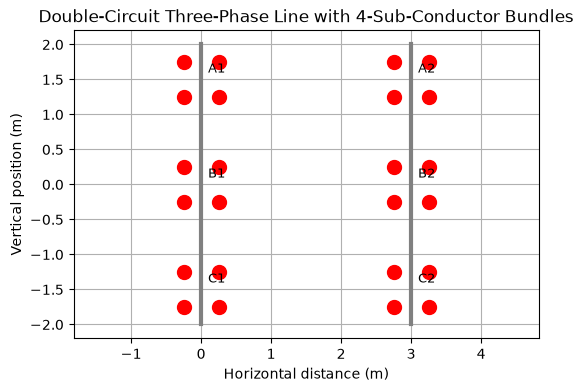

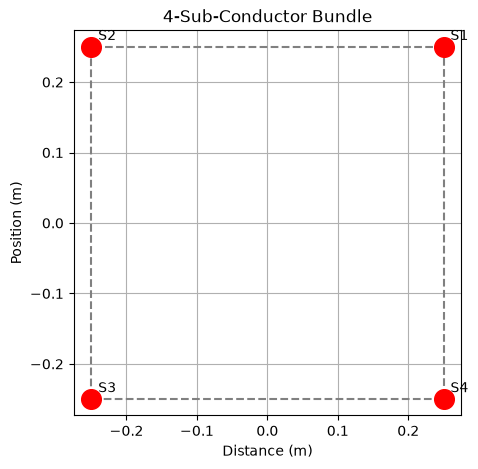

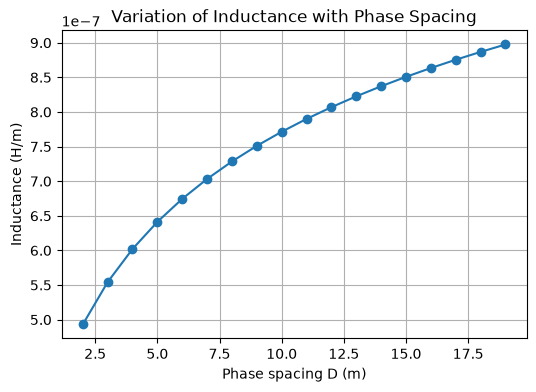

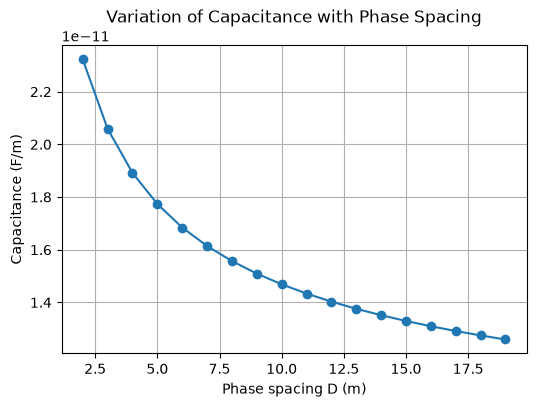

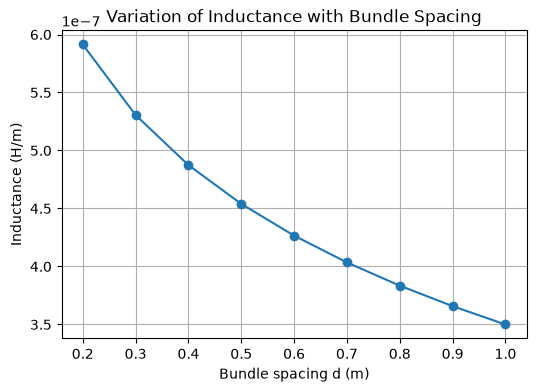

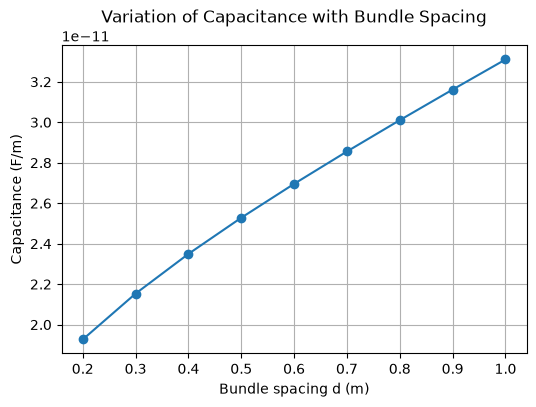

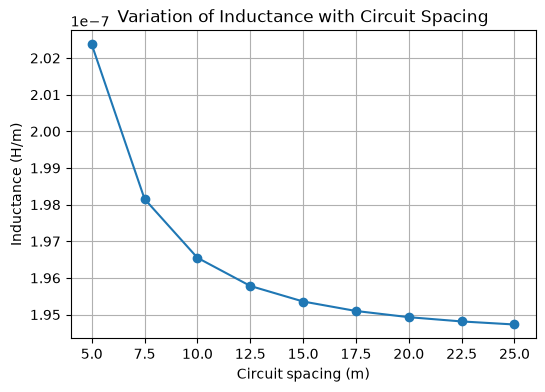

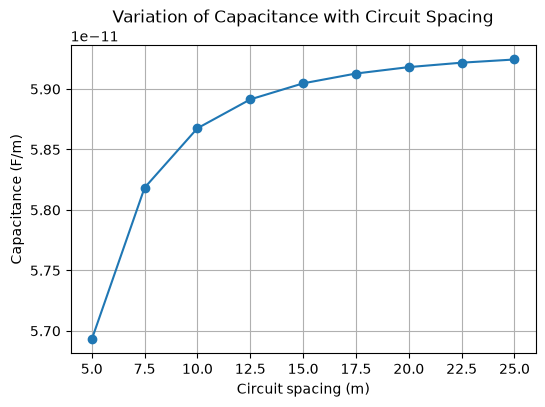


--- Effect of Number of Sub-Conductors ---
 Sub-conductors per bundle  Bundle GMR (m)  Equivalent Radius (m)  Double-Circuit GMR (m)  Inductance (H/m)  Capacitance (F/m)
                         2        0.123126               0.141421                0.607765      2.920967e-07       3.998756e-11
                         3        0.196437               0.215443                0.767666      2.453834e-07       4.711571e-11
                         4        0.270576               0.289982                0.900959      2.133624e-07       5.389703e-11


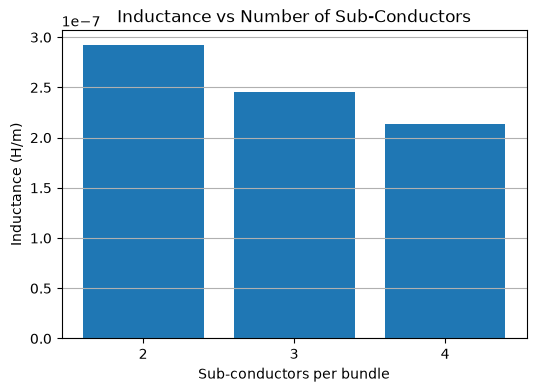

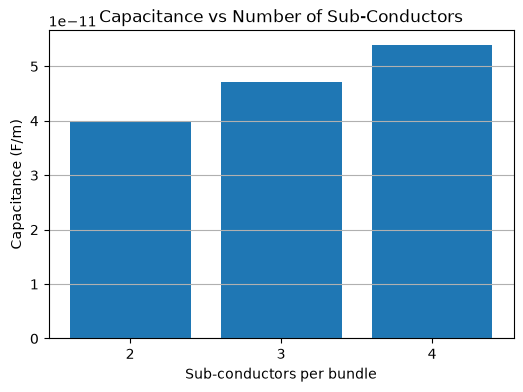


--- Conclusion ---
Increasing phase spacing increases GMD, which increases inductance and reduces capacitance.
Increasing the spacing between sub-conductors in a bundle increases the effective bundle GMR and equivalent radius.
The increase in effective bundle GMR reduces the inductance of the transmission line.
Increasing the number of sub-conductors in a bundle generally increases the effective GMR and reduces inductance.
The double-circuit arrangement causes the two circuits to interact through their conductor spacing, changing the effective GMD and GMR of the line.
The graphs show how phase spacing, bundle spacing, circuit spacing and the number of sub-conductors affect the transmission-line parameters.


In [5]:
# ============================================================
# CALCULATION OF GMR, GMD, INDUCTANCE AND CAPACITANCE
# FOR A DOUBLE-CIRCUIT THREE-PHASE TRANSMISSION LINE
# WITH BUNDLED CONDUCTORS
# ============================================================


# Import libraries
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# STEP 1: INPUT CONDUCTOR DATA
# ============================================================

# Types of conductor and their GMR factors:
#
# GMR = factor * physical radius

conductor_types = {
    "1": ("Solid round", 0.7788),
    "2": ("Stranded, 7 strands", 0.726),
    "3": ("Stranded, 19 strands", 0.758),
    "4": ("Stranded, 37 strands", 0.768),
    "5": ("ACSR 26/7", 0.81),
}


print("Conductor types:")

for key, value in conductor_types.items():
    print(f"  {key} - {value[0]}")


# Ask until a valid option is chosen

choice = input(
    "Select the type of conductor (1-5): "
)

while choice not in conductor_types:

    choice = input(
        "Invalid choice. Select the type of conductor (1-5): "
    )


conductor_name, factor = conductor_types[choice]


# Enter physical radius of ONE sub-conductor

r = float(input(
    "Enter sub-conductor radius r (in meters): "
))


# Calculate GMR of one sub-conductor

GMR = factor * r


# ============================================================
# STEP 2: INPUT BUNDLE DATA
# ============================================================

# Select the number of sub-conductors in each bundle.
#
# 2 -> Two sub-conductor bundle
# 3 -> Three sub-conductor bundle
# 4 -> Four sub-conductor bundle


print("\nNumber of sub-conductors per bundle:")

print("  2 - Two sub-conductor bundle")
print("  3 - Three sub-conductor bundle")
print("  4 - Four sub-conductor bundle")


N = input(
    "Select the number of sub-conductors per bundle (2-4): "
)


while N not in ["2", "3", "4"]:

    N = input(
        "Invalid choice. Select the number of sub-conductors "
        "per bundle (2-4): "
    )


N = int(N)


# Enter spacing between adjacent sub-conductors

d = float(input(
    "Enter bundle spacing d between adjacent sub-conductors "
    "(in meters): "
))


# ============================================================
# STEP 3: CALCULATE BUNDLE GMR AND EQUIVALENT RADIUS
# ============================================================


# Position of sub-conductors inside the bundle.
#
# 2 conductors -> horizontal pair
# 3 conductors -> equilateral triangle
# 4 conductors -> square


def bundle_positions(n, spacing):

    # Radius from bundle centre to each sub-conductor

    R = spacing / (
        2 * math.sin(math.pi / n)
    )


    # Starting angle for convenient orientation

    start_angles = {
        2: 0,
        3: 90,
        4: 45
    }


    start_angle = math.radians(
        start_angles[n]
    )


    angles = [
        start_angle +
        (2 * math.pi * k / n)
        for k in range(n)
    ]


    x = [
        R * math.cos(angle)
        for angle in angles
    ]


    y = [
        R * math.sin(angle)
        for angle in angles
    ]


    return x, y


# Calculate equivalent bundle GMR
# and equivalent radius for capacitance


def bundle_values(n, spacing):

    bx, by = bundle_positions(
        n,
        spacing
    )


    # Start with GMR and physical radius
    # of one sub-conductor

    product_gmr = GMR
    product_radius = r


    # Multiply by distances from the first
    # sub-conductor to the remaining sub-conductors

    for j in range(1, n):

        distance = math.hypot(
            bx[0] - bx[j],
            by[0] - by[j]
        )


        product_gmr *= distance
        product_radius *= distance


    # Equivalent bundle GMR

    GMR_bundle = product_gmr ** (
        1 / n
    )


    # Equivalent bundle radius for capacitance

    r_bundle = product_radius ** (
        1 / n
    )


    return GMR_bundle, r_bundle


# Calculate bundle values

GMR_bundle, r_bundle = bundle_values(
    N,
    d
)


# ============================================================
# STEP 4: INPUT DOUBLE-CIRCUIT LINE DIMENSIONS
# ============================================================

# Each circuit contains three phase bundles:
#
# Circuit 1 -> A1, B1, C1
# Circuit 2 -> A2, B2, C2
#
# The two circuits are separated horizontally.


# Distance between Phase A and Phase B

D_AB = float(input(
    "\nEnter distance between Phase A and Phase B "
    "in each circuit (m): "
))


# Distance between Phase B and Phase C

D_BC = float(input(
    "Enter distance between Phase B and Phase C "
    "in each circuit (m): "
))


# Distance between the two outer phases

D_AC = D_AB + D_BC


# Distance between the two circuits
# measured between corresponding phases

D_CC = float(input(
    "Enter spacing between the two circuits "
    "between corresponding phases (m): "
))


# ============================================================
# STEP 5: DEFINE POSITIONS OF THE SIX BUNDLES
# ============================================================

# Circuit 1 is placed at x = 0.
#
# Circuit 2 is placed at x = D_CC.
#
# The phase positions are:
#
# A -> upper
# B -> middle
# C -> lower


A1 = (0, D_BC)
B1 = (0, 0)
C1 = (0, -D_AB)


A2 = (D_CC, D_BC)
B2 = (D_CC, 0)
C2 = (D_CC, -D_AB)


# ============================================================
# STEP 6: DISTANCE FUNCTION
# ============================================================


def distance(point1, point2):

    return math.hypot(
        point1[0] - point2[0],
        point1[1] - point2[1]
    )


# ============================================================
# STEP 7: CALCULATE EFFECTIVE GMD FOR DOUBLE CIRCUIT
# ============================================================

# For each phase pair, calculate the geometric mean
# of the four distances between the corresponding
# phase bundles of the two circuits.


# A-B phase pair

D_A1B1 = distance(A1, B1)
D_A1B2 = distance(A1, B2)
D_A2B1 = distance(A2, B1)
D_A2B2 = distance(A2, B2)


GMD_AB = (
    D_A1B1 *
    D_A1B2 *
    D_A2B1 *
    D_A2B2
) ** (1 / 4)


# B-C phase pair

D_B1C1 = distance(B1, C1)
D_B1C2 = distance(B1, C2)
D_B2C1 = distance(B2, C1)
D_B2C2 = distance(B2, C2)


GMD_BC = (
    D_B1C1 *
    D_B1C2 *
    D_B2C1 *
    D_B2C2
) ** (1 / 4)


# C-A phase pair

D_C1A1 = distance(C1, A1)
D_C1A2 = distance(C1, A2)
D_C2A1 = distance(C2, A1)
D_C2A2 = distance(C2, A2)


GMD_CA = (
    D_C1A1 *
    D_C1A2 *
    D_C2A1 *
    D_C2A2
) ** (1 / 4)


# Overall GMD

GMD = (
    GMD_AB *
    GMD_BC *
    GMD_CA
) ** (1 / 3)


# ============================================================
# STEP 8: CALCULATE INDUCTANCE
# ============================================================

# Inductance per phase per metre:
#
# L = 2e-7 ln(GMD / GMR_bundle)


L = (
    2e-7 *
    math.log(
        GMD / GMR_bundle
    )
)


# ============================================================
# STEP 9: CALCULATE CAPACITANCE
# ============================================================

# Permittivity of free space

epsilon_0 = 8.854e-12


# Capacitance per phase per metre:
#
# C = (2*pi*epsilon_0) /
#     ln(GMD / r_bundle)


C = (
    2 * math.pi * epsilon_0
) / math.log(
    GMD / r_bundle
)


# ============================================================
# STEP 10: DISPLAY RESULTS
# ============================================================


print("\n--- Double-Circuit Transmission Line Parameters ---")


print(
    f"Conductor type = {conductor_name}"
)


print(
    f"Sub-conductors per bundle = {N}"
)


print(
    f"Sub-conductor radius = {r:.6f} m"
)


print(
    f"Sub-conductor GMR = {GMR:.6f} m"
)


print(
    f"Bundle spacing = {d:.6f} m"
)


print(
    f"Bundle GMR = {GMR_bundle:.6f} m"
)


print(
    f"Equivalent bundle radius = {r_bundle:.6f} m"
)


print(
    f"D_AB = {D_AB:.6f} m"
)


print(
    f"D_BC = {D_BC:.6f} m"
)


print(
    f"D_AC = {D_AC:.6f} m"
)


print(
    f"Circuit spacing = {D_CC:.6f} m"
)


print(
    f"GMD_AB = {GMD_AB:.6f} m"
)


print(
    f"GMD_BC = {GMD_BC:.6f} m"
)


print(
    f"GMD_CA = {GMD_CA:.6f} m"
)


print(
    f"Overall GMD = {GMD:.6f} m"
)


print(
    f"Inductance per phase = {L:.6e} H/m"
)


print(
    f"Capacitance per phase = {C:.6e} F/m"
)


# ============================================================
# STEP 11: VISUALIZATION OF DOUBLE-CIRCUIT ARRANGEMENT
# ============================================================


# Bundle centre positions

bundle_centres = [
    A1,
    B1,
    C1,
    A2,
    B2,
    C2
]


bundle_labels = [
    "A1",
    "B1",
    "C1",
    "A2",
    "B2",
    "C2"
]


# Obtain positions of sub-conductors
# inside one bundle

bx, by = bundle_positions(
    N,
    d
)


# Create figure

plt.figure(figsize=(6, 4))


# Draw first circuit vertical support

plt.plot(
    [0, 0],
    [-D_AB - 0.5, D_BC + 0.5],
    color="gray",
    linewidth=3
)


# Draw second circuit vertical support

plt.plot(
    [D_CC, D_CC],
    [-D_AB - 0.5, D_BC + 0.5],
    color="gray",
    linewidth=3
)


# Draw all bundles

for centre, label in zip(
    bundle_centres,
    bundle_labels
):

    for j in range(N):

        plt.scatter(
            centre[0] + bx[j],
            centre[1] + by[j],
            s=100,
            color="red",
            zorder=3
        )


    # Label bundle

    plt.annotate(
        label,
        centre,
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )


plt.title(
    f"Double-Circuit Three-Phase Line "
    f"with {N}-Sub-Conductor Bundles"
)


plt.xlabel(
    "Horizontal distance (m)"
)


plt.ylabel(
    "Vertical position (m)"
)


plt.grid(True)

plt.axis("equal")

plt.show()


# ============================================================
# STEP 12: SHOW ONE BUNDLE IN DETAIL
# ============================================================


plt.figure(figsize=(5, 5))


# Connect sub-conductors

plt.plot(
    bx + [bx[0]],
    by + [by[0]],
    linestyle="--",
    color="gray"
)


# Plot sub-conductors

plt.scatter(
    bx,
    by,
    s=200,
    color="red",
    zorder=3
)


# Label sub-conductors

for i in range(N):

    plt.annotate(
        f"S{i + 1}",
        (bx[i], by[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.title(
    f"{N}-Sub-Conductor Bundle"
)


plt.xlabel(
    "Distance (m)"
)


plt.ylabel(
    "Position (m)"
)


plt.grid(True)

plt.axis("equal")

plt.show()


# ============================================================
# STEP 13: VARIATION OF INDUCTANCE AND CAPACITANCE
# WITH PHASE SPACING
# ============================================================

# Keep circuit spacing fixed.
#
# Assume a symmetrical arrangement:
#
# D_AB = D
# D_BC = D
# D_AC = 2D


distances = [
    i for i in range(2, 20)
]


inductances = []

capacitances = []


# Calculate values for each phase spacing

for D in distances:

    # Temporary phase positions

    A1_var = (0, D)
    B1_var = (0, 0)
    C1_var = (0, -D)


    A2_var = (D_CC, D)
    B2_var = (D_CC, 0)
    C2_var = (D_CC, -D)


    # Calculate phase-pair GMDs

    GMD_AB_var = (
        distance(A1_var, B1_var) *
        distance(A1_var, B2_var) *
        distance(A2_var, B1_var) *
        distance(A2_var, B2_var)
    ) ** (1 / 4)


    GMD_BC_var = (
        distance(B1_var, C1_var) *
        distance(B1_var, C2_var) *
        distance(B2_var, C1_var) *
        distance(B2_var, C2_var)
    ) ** (1 / 4)


    GMD_CA_var = (
        distance(C1_var, A1_var) *
        distance(C1_var, A2_var) *
        distance(C2_var, A1_var) *
        distance(C2_var, A2_var)
    ) ** (1 / 4)


    # Overall GMD

    GMD_var = (
        GMD_AB_var *
        GMD_BC_var *
        GMD_CA_var
    ) ** (1 / 3)


    # Inductance

    L_var = (
        2e-7 *
        math.log(
            GMD_var / GMR_bundle
        )
    )


    # Capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD_var / r_bundle
    )


    inductances.append(L_var)

    capacitances.append(C_var)


# ============================================================
# STEP 14: PLOT INDUCTANCE VS PHASE SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    distances,
    inductances,
    marker="o"
)


plt.title(
    "Variation of Inductance with Phase Spacing"
)


plt.xlabel(
    "Phase spacing D (m)"
)


plt.ylabel(
    "Inductance (H/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 15: PLOT CAPACITANCE VS PHASE SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    distances,
    capacitances,
    marker="o"
)


plt.title(
    "Variation of Capacitance with Phase Spacing"
)


plt.xlabel(
    "Phase spacing D (m)"
)


plt.ylabel(
    "Capacitance (F/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 16: VARIATION WITH BUNDLE SPACING
# ============================================================

# Keep phase spacing and circuit spacing fixed.
#
# Vary the distance between sub-conductors
# inside each bundle.


bundle_spacings = np.linspace(
    0.2,
    1.0,
    9
)


bundle_inductances = []

bundle_capacitances = []


for spacing in bundle_spacings:

    # Calculate bundle GMR and equivalent radius

    GMR_var, r_var = bundle_values(
        N,
        spacing
    )


    # Calculate inductance

    L_var = (
        2e-7 *
        math.log(
            GMD / GMR_var
        )
    )


    # Calculate capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD / r_var
    )


    bundle_inductances.append(
        L_var
    )


    bundle_capacitances.append(
        C_var
    )


# ============================================================
# STEP 17: PLOT INDUCTANCE VS BUNDLE SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    bundle_spacings,
    bundle_inductances,
    marker="o"
)


plt.title(
    "Variation of Inductance with Bundle Spacing"
)


plt.xlabel(
    "Bundle spacing d (m)"
)


plt.ylabel(
    "Inductance (H/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 18: PLOT CAPACITANCE VS BUNDLE SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    bundle_spacings,
    bundle_capacitances,
    marker="o"
)


plt.title(
    "Variation of Capacitance with Bundle Spacing"
)


plt.xlabel(
    "Bundle spacing d (m)"
)


plt.ylabel(
    "Capacitance (F/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 19: VARIATION WITH CIRCUIT SPACING
# ============================================================

# Keep phase spacing and bundle spacing fixed.
#
# Vary the distance between the two circuits.


circuit_spacings = np.linspace(
    5,
    25,
    9
)


circuit_inductances = []

circuit_capacitances = []


for spacing in circuit_spacings:

    # Temporary positions

    A1_var = (0, D_BC)
    B1_var = (0, 0)
    C1_var = (0, -D_AB)


    A2_var = (spacing, D_BC)
    B2_var = (spacing, 0)
    C2_var = (spacing, -D_AB)


    # Calculate GMDs

    GMD_AB_var = (
        distance(A1_var, B1_var) *
        distance(A1_var, B2_var) *
        distance(A2_var, B1_var) *
        distance(A2_var, B2_var)
    ) ** (1 / 4)


    GMD_BC_var = (
        distance(B1_var, C1_var) *
        distance(B1_var, C2_var) *
        distance(B2_var, C1_var) *
        distance(B2_var, C2_var)
    ) ** (1 / 4)


    GMD_CA_var = (
        distance(C1_var, A1_var) *
        distance(C1_var, A2_var) *
        distance(C2_var, A1_var) *
        distance(C2_var, A2_var)
    ) ** (1 / 4)


    # Overall GMD

    GMD_var = (
        GMD_AB_var *
        GMD_BC_var *
        GMD_CA_var
    ) ** (1 / 3)


    # Calculate equivalent GMR for the
    # double-circuit arrangement.
    #
    # The same-phase bundle centres are
    # separated by the circuit spacing.


    GMR_double = math.sqrt(
        GMR_bundle * spacing
    )


    # Calculate inductance

    L_var = (
        2e-7 *
        math.log(
            GMD_var / GMR_double
        )
    )


    # Equivalent radius for capacitance

    r_double = math.sqrt(
        r_bundle * spacing
    )


    # Calculate capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD_var / r_double
    )


    circuit_inductances.append(
        L_var
    )


    circuit_capacitances.append(
        C_var
    )


# ============================================================
# STEP 20: PLOT INDUCTANCE VS CIRCUIT SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    circuit_spacings,
    circuit_inductances,
    marker="o"
)


plt.title(
    "Variation of Inductance with Circuit Spacing"
)


plt.xlabel(
    "Circuit spacing (m)"
)


plt.ylabel(
    "Inductance (H/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 21: PLOT CAPACITANCE VS CIRCUIT SPACING
# ============================================================


plt.figure(figsize=(6, 4))


plt.plot(
    circuit_spacings,
    circuit_capacitances,
    marker="o"
)


plt.title(
    "Variation of Capacitance with Circuit Spacing"
)


plt.xlabel(
    "Circuit spacing (m)"
)


plt.ylabel(
    "Capacitance (F/m)"
)


plt.grid(True)

plt.show()


# ============================================================
# STEP 22: EFFECT OF NUMBER OF SUB-CONDUCTORS
# ============================================================

# Compare:
#
# 2 sub-conductors
# 3 sub-conductors
# 4 sub-conductors
#
# using the same conductor, bundle spacing,
# phase spacing and circuit spacing.


numbers = [2, 3, 4]


L_numbers = []

C_numbers = []


for n in numbers:

    # Bundle GMR and equivalent radius

    g_n, r_n = bundle_values(
        n,
        d
    )


    # Equivalent GMR for the double-circuit arrangement

    GMR_double_n = math.sqrt(
        g_n * D_CC
    )


    # Equivalent radius for capacitance

    r_double_n = math.sqrt(
        r_n * D_CC
    )


    # Inductance

    L_n = (
        2e-7 *
        math.log(
            GMD / GMR_double_n
        )
    )


    # Capacitance

    C_n = (
        2 * math.pi * epsilon_0
    ) / math.log(
        GMD / r_double_n
    )


    L_numbers.append(
        L_n
    )


    C_numbers.append(
        C_n
    )


# Create comparison table

bundle_table = pd.DataFrame({

    "Sub-conductors per bundle": numbers,

    "Bundle GMR (m)": [
        bundle_values(n, d)[0]
        for n in numbers
    ],

    "Equivalent Radius (m)": [
        bundle_values(n, d)[1]
        for n in numbers
    ],

    "Double-Circuit GMR (m)": [
        math.sqrt(
            bundle_values(n, d)[0] * D_CC
        )
        for n in numbers
    ],

    "Inductance (H/m)": L_numbers,

    "Capacitance (F/m)": C_numbers

})


print(
    "\n--- Effect of Number of Sub-Conductors ---"
)


print(
    bundle_table.to_string(
        index=False
    )
)


# ============================================================
# STEP 23: PLOT EFFECT OF NUMBER OF SUB-CONDUCTORS
# ============================================================


plt.figure(figsize=(6, 4))


plt.bar(
    [str(n) for n in numbers],
    L_numbers
)


plt.title(
    "Inductance vs Number of Sub-Conductors"
)


plt.xlabel(
    "Sub-conductors per bundle"
)


plt.ylabel(
    "Inductance (H/m)"
)


plt.grid(
    True,
    axis="y"
)


plt.show()


# Capacitance comparison

plt.figure(figsize=(6, 4))


plt.bar(
    [str(n) for n in numbers],
    C_numbers
)


plt.title(
    "Capacitance vs Number of Sub-Conductors"
)


plt.xlabel(
    "Sub-conductors per bundle"
)


plt.ylabel(
    "Capacitance (F/m)"
)


plt.grid(
    True,
    axis="y"
)


plt.show()


# ============================================================
# STEP 24: CONCLUSION
# ============================================================


print("\n--- Conclusion ---")


print(
    "Increasing phase spacing increases GMD, "
    "which increases inductance and reduces capacitance."
)


print(
    "Increasing the spacing between sub-conductors "
    "in a bundle increases the effective bundle GMR "
    "and equivalent radius."
)


print(
    "The increase in effective bundle GMR reduces "
    "the inductance of the transmission line."
)


print(
    "Increasing the number of sub-conductors in a bundle "
    "generally increases the effective GMR and reduces "
    "inductance."
)


print(
    "The double-circuit arrangement causes the two circuits "
    "to interact through their conductor spacing, changing "
    "the effective GMD and GMR of the line."
)


print(
    "The graphs show how phase spacing, bundle spacing, "
    "circuit spacing and the number of sub-conductors "
    "affect the transmission-line parameters."
)